In [1]:
from olg import search_equilibrium
from setting import Setting
from utils import *
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
baseline = search_equilibrium(
    Setting(),
    Kd0 = 500,
    lambdaR = 0.01,
    DEBUG_MODE=False
)

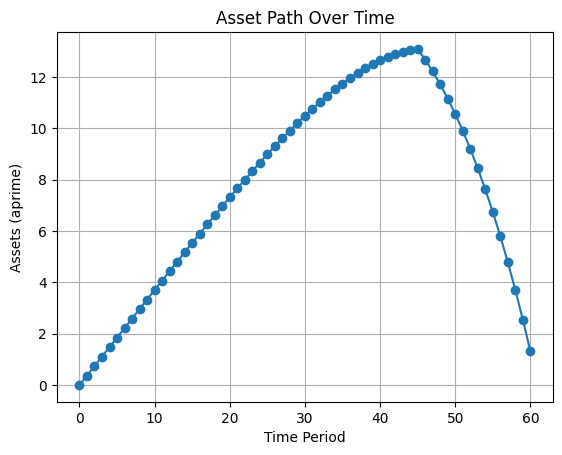

In [3]:
# aprime_pathをプロット（x軸を20から）
plt.plot(baseline.equilibrium.aprime_path, marker='o')
plt.title('Asset Path Over Time')
plt.xlabel('Time Period')
plt.ylabel('Assets (aprime)')
plt.grid()
plt.show()

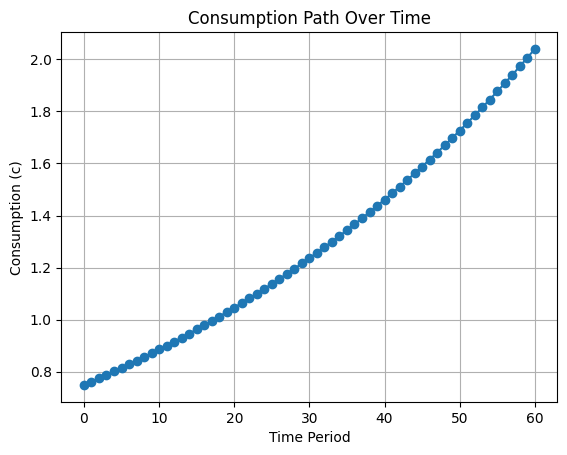

In [4]:
# c_pathをプロット（x軸を20から）
plt.plot(baseline.equilibrium.c_path, marker='o')
plt.title('Consumption Path Over Time')
plt.xlabel('Time Period')
plt.ylabel('Consumption (c)')
plt.grid()
plt.show()

In [12]:
# シナリオごとに解く
# 所得代替率の半減
low_replacement_rate = search_equilibrium(
    Setting(psi=0.25),
    Kd0 = 500,
    lambdaR = 0.01,
    DEBUG_MODE=False
)
# 定年引き上げ（労働が50期間, 年金受給者/総人口が減少、労働者/総人口が増加）
retire_at_71 = search_equilibrium(
    Setting(jr=51), #引退期の開始が51歳
    Kd0 = 500,
    lambdaR = 0.01,
    DEBUG_MODE=False
)
# 高齢化（年金受給者/総人口が増加、労働者/総人口が減少）
live_to_85 = search_equilibrium(
    Setting(J =66), # 20〜85 歳 → 66 期、NjW（労働機関）はベースラインのまま（45 期）
    Kd0 = 500,
    lambdaR = 0.01,
    DEBUG_MODE=False
)
work_until_death = search_equilibrium( # 生涯現役、死ぬまで働く
    Setting(jr = 62),
    Kd0 = 500,
    lambdaR = 0.01,
    DEBUG_MODE=False
)


senarios = {
    "baseline": baseline,
    "low_replacement_rate": low_replacement_rate,
    "retire_at_71": retire_at_71,
    "live_to_85": live_to_85,
    "work_until_death": work_until_death
}

In [13]:
rows = []
for key, result in senarios.items():
    rows.append({
            "Scenario": key,
            'K': 100*(result.equilibrium.K_star - baseline.equilibrium.K_star)/baseline.equilibrium.K_star,
            'K/L': 100*(result.equilibrium.K_star/result.equilibrium.L_star - baseline.equilibrium.K_star/baseline.equilibrium.L_star)/baseline.equilibrium.K_star*baseline.equilibrium.L_star,
            'r': 100*(result.equilibrium.r_star),
            'w': 100*(result.equilibrium.w_star - baseline.equilibrium.w_star)/baseline.equilibrium.w_star,
            'tau': 100*result.equilibrium.tau,
            'ss_toal': result.equilibrium.p * (result.setting.J - result.setting.jr + 1)
    })
df = pd.DataFrame(rows)
for col in ['K','K/L', 'w']:
    df[col] = df[col].apply(lambda x: f"{x:+.1f}%")
for col in ['r', 'tau']:
    df[col] = df[col].apply(lambda x: f"{x:.1f}%")
print(df)

               Scenario       K    K/L     r      w    tau    ss_toal
0              baseline   +0.0%  +0.0%  3.8%  +0.0%  17.8%  10.856943
1  low_replacement_rate   +8.9%  +8.9%  3.2%  +3.5%   8.9%   5.616961
2          retire_at_71   +1.0%  +1.0%  3.7%  +0.4%  11.0%   7.492952
3            live_to_85  +10.2%  +1.9%  3.6%  +0.7%  23.3%  14.356215
4      work_until_death   -1.2%  -1.2%  3.8%  -0.5%   0.0%   0.000000
